<a href="https://colab.research.google.com/github/HenryZumaeta/py4cd_EPC2025/blob/main/C20/C20_Script01_AnalisisDatosFaltantes_RegresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Datos y modulos
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Datos
life = pd.read_csv("https://raw.githubusercontent.com/robintux/Datasets4StackOverFlowQuestions/refs/heads/master/Life_Expectancy_Data.csv")
life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [2]:
# Arreglemos los nombres de las columnas
life.columns = life.columns.str.strip()

# Creacion de identificador único para análisis longitudinal
life["Country_Year"] = life["Country"] + "_" + life["Year"].astype(str)

print(f"Dimensión del dataset: {life.shape}")
print(f"\nVariables Categóricas: {life.select_dtypes(include = "object").columns.tolist()}")
print(f"Paises: {life["Country"].nunique()}")
print(f"Rango Temporal: {life["Year"].min()} - {life["Year"].max()}")
print(f"Distribución de Status: {life["Status"].value_counts(normalize = True).mul(100).round(2)}")

Dimensión del dataset: (2938, 23)

Variables Categóricas: ['Country', 'Status', 'Country_Year']
Paises: 193
Rango Temporal: 2000 - 2015
Distribución de Status: Status
Developing    82.57
Developed     17.43
Name: proportion, dtype: float64


# Valores faltantes

In [3]:
# Valores faltantes por columna
life.isnull().sum().sort_values(ascending = False)

,0
Population,652
Hepatitis B,553
GDP,448
Total expenditure,226
Alcohol,194
Income composition of resources,167
Schooling,163
thinness 1-19 years,34
thinness 5-9 years,34
BMI,34


## Mecanismos de Missingnness

* MCAR (Missing Completely At Random)
* MAR (Missing At Random)
* MNAR (Missing Not At Random)

## Deteción de patrones de missingness

* Proporción de faltantes por columna
* Test de Little (Prueba MCAR, H0: MCAR)
* Análisis predictivo de missingness
* Comparación de distribuciones

In [4]:
# Matriz de completitud con analisis estructural de missingness (faltantes)
missing_data = pd.DataFrame({
    "Variable" : life.columns,
    "Valores_Nulos" : life.isnull().sum(),
    "Porcentaje_Nulos" : (life.isnull().sum()/len(life)*100).round(2),
    "Tipo" : life.dtypes
}).sort_values(by = "Porcentaje_Nulos", ascending= False)

missing_data[missing_data["Valores_Nulos"] > 0]

,Variable,Valores_Nulos,Porcentaje_Nulos,Tipo
Population,Population,652,22.19,float64
Hepatitis B,Hepatitis B,553,18.82,float64
GDP,GDP,448,15.25,float64
Total expenditure,Total expenditure,226,7.69,float64
Alcohol,Alcohol,194,6.60,float64
Income composition of resources,Income composition of resources,167,5.68,float64
Schooling,Schooling,163,5.55,float64
thinness 1-19 years,thinness 1-19 years,34,1.16,float64
thinness 5-9 years,thinness 5-9 years,34,1.16,float64
BMI,BMI,34,1.16,float64


Text(0.5, 1.0, 'Patron Estructural de Valores Faltantes')

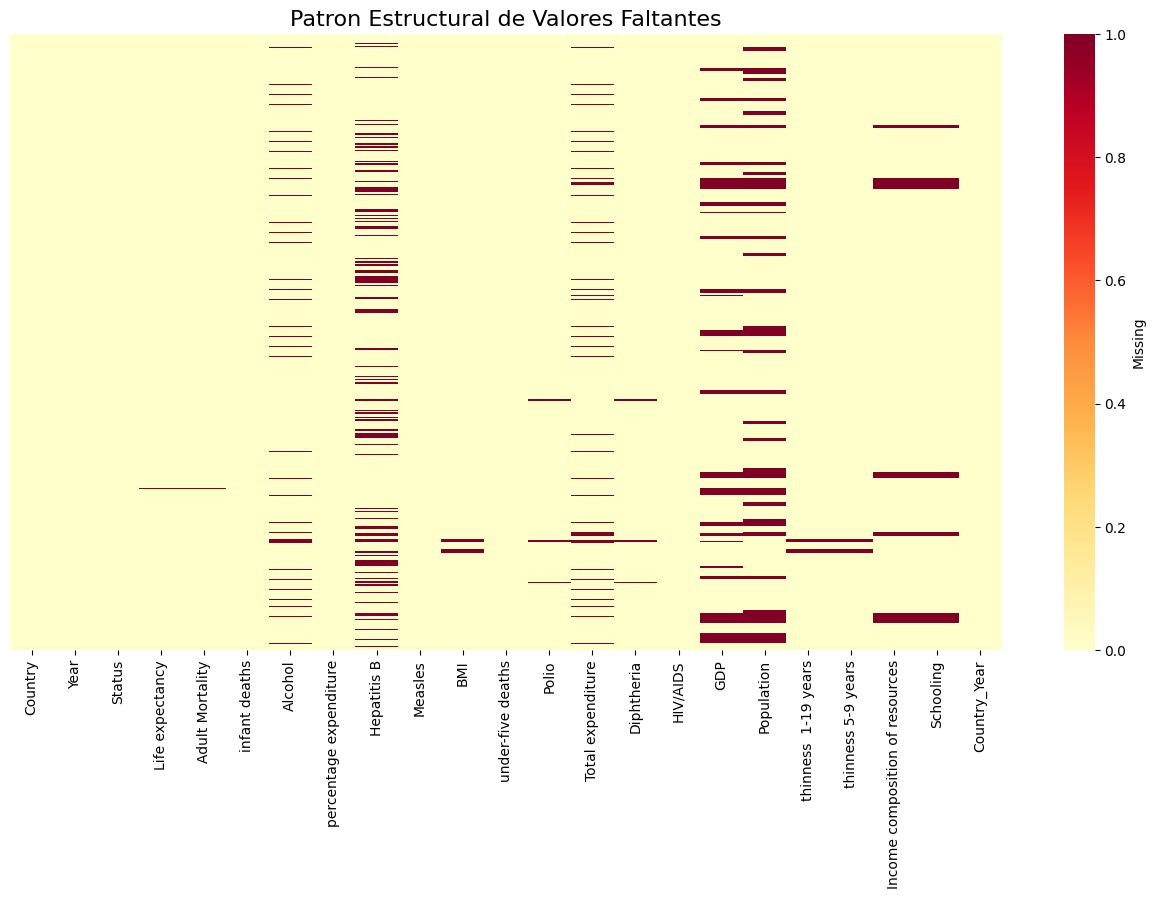

In [5]:
# Visualicemos a los valores faltantes (missingness) (MCAR, MAR, MNAR)
plt.figure(figsize = (16,8))
sns.heatmap(life.isnull(), cbar_kws = {"label": "Missing"}, cmap = "YlOrRd", yticklabels=False)
plt.title("Patron Estructural de Valores Faltantes", fontsize = 16)

In [6]:
# Variables con >15% de missingness requieren algunas técnicas de Imputación Múltiple (Bayesiana)
missing_data[missing_data["Porcentaje_Nulos"]> 15][["Variable", "Porcentaje_Nulos"]]

,Variable,Porcentaje_Nulos
Population,Population,22.19
Hepatitis B,Hepatitis B,18.82
GDP,GDP,15.25


In [7]:
life

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Country_Year
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,Afghanistan_2015
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,Afghanistan_2014
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,Afghanistan_2013
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,Afghanistan_2012
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,Afghanistan_2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,Zimbabwe_2004
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,Zimbabwe_2003
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,Zimbabwe_2002
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,Zimbabwe_2001


In [ ]:
# Calculo del test de Little:
# Si los datos faltantes son netamente aleatorioa (MCAR).
# H0: El mecanismo de datos faltantes, no están relacionados con los valores observados
# ni con los no observados. Sugiere que los datos faltantes son MCAR+
# La prueba asume normalidad multivariada, el chi cuadrado lo define en función
# de los grados de libertad, entonces es sensible al tamaño de la muestra, no destinge MAR y MNAR, solo detecta si no es MCAR

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import chi2


def _safe_inverse(matrix: np.ndarray, ridge: float = 1e-8) -> np.ndarray:
    """
    Inversa numéricamente estable.
    Si la matriz es casi singular, añade una regularización diagonal.
    """
    matrix = np.asarray(matrix, dtype=float)
    reg_matrix = matrix + np.eye(matrix.shape[0]) * ridge
    return np.linalg.pinv(reg_matrix)


def _em_mean_cov(X: np.ndarray, max_iter: int = 200, tol: float = 1e-6, ridge: float = 1e-8):
    """
    Estima media y covarianza usando EM para datos faltantes bajo
    normalidad multivariante.

    Parámetros
    ----------
    X : np.ndarray
        Matriz n x p con np.nan en faltantes.
    max_iter : int
        Número máximo de iteraciones EM.
    tol : float
        Tolerancia de convergencia.
    ridge : float
        Regularización diagonal para estabilidad numérica.

    Retorna
    -------
    mu : np.ndarray
        Vector media estimado.
    Sigma : np.ndarray
        Matriz de covarianza estimada.
    """
    X = np.asarray(X, dtype=float)
    n, p = X.shape

    # Inicialización con medias por columna
    col_means = np.nanmean(X, axis=0)

    # Si alguna columna está completamente vacía, error explícito
    if np.any(np.isnan(col_means)):
        cols_all_nan = np.where(np.isnan(col_means))[0]
        raise ValueError(
            f"Las columnas {cols_all_nan.tolist()} tienen todos sus valores faltantes. "
            "El test de Little no puede estimarse en esas condiciones."
        )

    X_imp = X.copy()
    inds = np.where(np.isnan(X_imp))
    X_imp[inds] = np.take(col_means, inds[1])

    mu = X_imp.mean(axis=0)
    Sigma = np.cov(X_imp, rowvar=False, bias=True)

    if Sigma.ndim == 0:
        Sigma = np.array([[Sigma]])

    Sigma = Sigma + np.eye(p) * ridge

    for _ in range(max_iter):
        Ex_sum = np.zeros(p)
        Exx_sum = np.zeros((p, p))

        for i in range(n):
            row = X[i, :]
            obs = ~np.isnan(row)
            mis = np.isnan(row)

            x_hat = np.zeros(p)
            S_i = np.zeros((p, p))

            if np.all(obs):
                x_hat = row.copy()

            elif np.all(mis):
                # Caso extremo: fila totalmente faltante
                x_hat = mu.copy()
                S_i = Sigma.copy()

            else:
                o = np.where(obs)[0]
                m = np.where(mis)[0]

                x_o = row[o]
                mu_o = mu[o]
                mu_m = mu[m]

                Sigma_oo = Sigma[np.ix_(o, o)]
                Sigma_mo = Sigma[np.ix_(m, o)]
                Sigma_om = Sigma[np.ix_(o, m)]
                Sigma_mm = Sigma[np.ix_(m, m)]

                Sigma_oo_inv = _safe_inverse(Sigma_oo, ridge=ridge)

                cond_mean_m = mu_m + Sigma_mo @ Sigma_oo_inv @ (x_o - mu_o)
                cond_cov_m = Sigma_mm - Sigma_mo @ Sigma_oo_inv @ Sigma_om

                x_hat[o] = x_o
                x_hat[m] = cond_mean_m

                S_i[np.ix_(m, m)] = cond_cov_m

            Ex_sum += x_hat
            Exx_sum += np.outer(x_hat, x_hat) + S_i

        mu_new = Ex_sum / n
        Sigma_new = Exx_sum / n - np.outer(mu_new, mu_new)

        # Regularización
        Sigma_new = (Sigma_new + Sigma_new.T) / 2
        Sigma_new += np.eye(p) * ridge

        delta_mu = np.max(np.abs(mu_new - mu))
        delta_sigma = np.max(np.abs(Sigma_new - Sigma))

        mu, Sigma = mu_new, Sigma_new

        if max(delta_mu, delta_sigma) < tol:
            break

    return mu, Sigma


def little_mcar_test(df: pd.DataFrame, max_iter: int = 200, tol: float = 1e-6, ridge: float = 1e-8):
    """
    Test de Little para MCAR.

    Hipótesis:
    H0: los datos faltantes son MCAR.
    H1: los datos faltantes no son MCAR.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con variables numéricas y np.nan como faltantes.
    max_iter : int
        Máximo número de iteraciones EM.
    tol : float
        Tolerancia de convergencia EM.
    ridge : float
        Regularización diagonal.

    Retorna
    -------
    result : dict
        {
            'statistic': float,
            'df': int,
            'p_value': float,
            'missing_patterns': int,
            'n_rows_used': int,
            'conclusion_0_05': str
        }
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("La entrada debe ser un pandas.DataFrame.")

    # Nos quedamos solo con columnas numéricas
    data = df.select_dtypes(include=[np.number]).copy()

    if data.shape[1] == 0:
        raise ValueError("No hay columnas numéricas en el DataFrame.")

    # Eliminar filas totalmente observadas? No, deben permanecer
    # porque influyen en la estimación EM.
    X = data.to_numpy(dtype=float)
    n, p = X.shape

    # Estimar mu y Sigma bajo el supuesto nulo
    mu_hat, Sigma_hat = _em_mean_cov(X, max_iter=max_iter, tol=tol, ridge=ridge)

    # Construcción de patrones de faltantes
    # pattern = True si observado, False si faltante
    obs_mask = ~np.isnan(X)
    pattern_strings = [''.join(row.astype(int).astype(str)) for row in obs_mask]
    pattern_series = pd.Series(pattern_strings, index=data.index)

    d2 = 0.0
    df_total = 0
    n_patterns = 0

    for pattern, idx in pattern_series.groupby(pattern_series).groups.items():
        rows_idx = list(idx)
        group = X[rows_idx, :]
        obs = obs_mask[rows_idx[0], :]  # mismo patrón en todo el grupo
        p_g = int(obs.sum())

        # Si una fila tiene todo faltante, no aporta al estadístico
        if p_g == 0:
            continue

        n_g = group.shape[0]
        observed_cols = np.where(obs)[0]

        # Media observada del grupo para las variables observadas en ese patrón
        group_mean = np.nanmean(group[:, observed_cols], axis=0)

        mu_g = mu_hat[observed_cols]
        Sigma_g = Sigma_hat[np.ix_(observed_cols, observed_cols)]
        Sigma_g_inv = _safe_inverse(Sigma_g, ridge=ridge)

        diff = group_mean - mu_g
        d2 += n_g * (diff.T @ Sigma_g_inv @ diff)

        df_total += p_g
        n_patterns += 1

    df_chi = df_total - p
    if df_chi <= 0:
        raise ValueError(
            "Los grados de libertad calculados no son válidos. "
            "Esto suele ocurrir con muy pocas observaciones o patrones insuficientes."
        )

    p_value = 1 - chi2.cdf(d2, df_chi)

    conclusion = (
        "No se rechaza H0 → el patrón de faltantes es compatible con MCAR."
        if p_value > 0.05
        else "Se rechaza H0 → el patrón de faltantes no es compatible con MCAR."
    )

    return {
        "statistic": float(d2),
        "df": int(df_chi),
        "p_value": float(p_value),
        "missing_patterns": int(n_patterns),
        "n_rows_used": int(n),
        "conclusion_0_05": conclusion
    }

In [9]:
# Ejemplo de datos para el Test de Little
df = pd.DataFrame({
    "x1": [1.2, 2.3, np.nan, 4.5, 5.1, np.nan, 7.2],
    "x2": [2.1, np.nan, 3.3, 4.2, 5.5, 6.1, np.nan],
    "x3": [1.0, 2.0, 3.0, np.nan, 5.0, 6.0, 7.0],
    "x4": [np.nan, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]
})

resultado = little_mcar_test(df)

print("Estadístico χ²:", resultado["statistic"])
print("gl:", resultado["df"])
print("p-value:", resultado["p_value"])
print("Patrones de faltantes:", resultado["missing_patterns"])
print("Conclusión:", resultado["conclusion_0_05"])

Estadístico χ²: 14.825786774022676
gl: 12
p-value: 0.2511022634976683
Patrones de faltantes: 5
Conclusión: No se rechaza H0 → el patrón de faltantes es compatible con MCAR.


In [ ]:
# Aplicando a los datos
resultado = little_mcar_test(life)

print("Estadístico χ²:", resultado["statistic"])
print("gl:", resultado["df"])
print("p-value:", resultado["p_value"])
print("Patrones de faltantes:", resultado["missing_patterns"])
print("Conclusión:", resultado["conclusion_0_05"])

Estadístico χ²: 2971.3419693091296
gl: 625
p-value: 0.0
Patrones de faltantes: 40
Conclusión: Se rechaza H0 → el patrón de faltantes no es compatible con MCAR.


In [ ]:
# No Cuantificar la asociación entre missingness y variables observadas
  # Variables Observadas -> MAR(MICE)
  # Variables no observadas -> MNAR (modelos pattern-mixture)

In [10]:
# Instalar el modulo: miceforest
!pip install miceforest

In [11]:
life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [12]:
# https://gist.github.com/robintux/c55a61e84a92f868842450aae830a2a2

import pandas as pd
import numpy as np
import miceforest as mf

def impute_life_expectancy_data_robust(df):
    """
    Pipeline de imputación diferenciada con manejo explícito de tipos de datos.
    Soluciona el error de columnas 'object' en miceforest mediante:
    1. Conversión de categóricas a tipo 'category'
    2. Exclusión de identificadores del kernel MICE
    3. Imputación temporal para variables epidemiológicas
    4. Fallback a sklearn si miceforest falla
    """
    df_imp = df.copy()

    # === PASO 1: Diagnóstico y preparación de tipos ===
    print("Diagnóstico inicial de tipos de datos:")
    print(df_imp.dtypes.value_counts())

    # Convertir Status a tipo categórico (requerido por miceforest)
    df_imp['Status'] = df_imp['Status'].astype('category')

    # Crear versión dummy para Status (alternativa robusta)
    df_imp['Status_Developed'] = (df_imp['Status'] == 'Developed').astype(int)

    # === PASO 2: Imputación temporal para variables MCAR (Life expectancy, Adult Mortality) ===
    print("\nImputación temporal por país para variables epidemiológicas...")
    for country in df_imp['Country'].unique():
        mask = df_imp['Country'] == country
        # Interpolación lineal bidireccional (forward + backward fill)
        df_imp.loc[mask, 'Life expectancy'] = (
            df_imp.loc[mask, 'Life expectancy']
            .interpolate(method='linear', limit_direction='both')
        )
        df_imp.loc[mask, 'Adult Mortality'] = (
            df_imp.loc[mask, 'Adult Mortality']
            .interpolate(method='linear', limit_direction='both')
        )

    # === PASO 3: Definir variables para MICE (SOLO numéricas + categóricas convertidas) ===
    mice_vars = [
        'GDP',
        'Income composition of resources',
        'Schooling',
        'percentage expenditure',
        'Total expenditure',
        'Alcohol',
        'BMI',
        'Hepatitis B',
        'Polio',
        'Diphtheria',
        'thinness  1-19 years',
        'thinness 5-9 years'
    ]

    # Variables predictoras (excluyendo identificadores object)
    predictor_vars = mice_vars + ['Status_Developed', 'Year', 'HIV/AIDS', 'infant deaths']

    # Crear subset limpio para MICE (solo columnas compatibles)
    df_mice = df_imp[predictor_vars].copy()

    # Verificación crítica: ninguna columna debe ser 'object'
    assert df_mice.select_dtypes(include=['object']).empty, \
        f"Columnas object detectadas: {df_mice.select_dtypes(include=['object']).columns.tolist()}"

    print(f"\nVariables en kernel MICE: {len(df_mice.columns)}")
    print(f"Missingness inicial en GDP: {df_mice['GDP'].isnull().sum()} ({df_mice['GDP'].isnull().mean()*100:.1f}%)")

    # === PASO 4: Imputación MICE con diagnóstico de convergencia ===
    try:
        kernel = mf.ImputationKernel(
            df_mice,
            save_all_iterations_data=True,
            random_state=42
        )
        kernel.mice(5, verbose=True)  # 5 iteraciones para robustez

        # Extraer dataset completo imputado
        df_mice_complete = kernel.complete_data(iteration=-1)

        # Reemplazar valores imputados en dataframe principal
        for col in mice_vars:
            df_imp[col] = df_mice_complete[col]

        print(f"\n✓ Imputación MICE exitosa")
        print(f"Missingness final en GDP: {df_imp['GDP'].isnull().sum()} ({df_imp['GDP'].isnull().mean()*100:.1f}%)")

    except AssertionError as e:
        print(f"\n  Error en miceforest: {e}")
        print("Fallback a IterativeImputer de sklearn...")
        df_imp = fallback_sklearn_imputation(df_imp, mice_vars)

    # === PASO 5: Manejo de variables MNAR (Population) ===
    df_imp['Population_missing'] = df_imp['Population'].isnull().astype(int)
    # NO imputamos Population (MNAR sospechoso) - mantenemos missingness como feature

    return df_imp

def fallback_sklearn_imputation(df, variables_to_impute):
    """
    Fallback robusto usando sklearn cuando miceforest falla.
    Más lento pero compatible con cualquier tipo de dato numérico.
    """
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer

    df_fallback = df.copy()

    # Seleccionar solo variables numéricas para imputación
    numeric_vars = [col for col in variables_to_impute if df_fallback[col].dtype in [np.float64, np.int64]]

    imputer = IterativeImputer(
        max_iter=10,
        random_state=42,
        verbose=1,
        initial_strategy='median'  # Más robusto que 'mean' para outliers
    )

    # Imputar solo las variables seleccionadas
    df_fallback[numeric_vars] = imputer.fit_transform(df_fallback[numeric_vars])

    print(f" Fallback sklearn completado para {len(numeric_vars)} variables")
    return df_fallback

In [13]:
life_imp = impute_life_expectancy_data_robust(life)
life_imp.info()

Diagnóstico inicial de tipos de datos:
float64    16
int64       4
object      3
Name: count, dtype: int64

Imputación temporal por país para variables epidemiológicas...

Variables en kernel MICE: 16
Missingness inicial en GDP: 448 (15.2%)
Initialized logger with name MICE Iterations 1 - 5 and 4 levels
1 Dataset 0
 | Polio | Diphtheria | thinness  1-19 years | BMI | thinness 5-9 years | Schooling | Income composition of resources | Alcohol | Total expenditure | GDP | Hepatitis B
2 Dataset 0
 | Polio | Diphtheria | thinness  1-19 years | BMI | thinness 5-9 years | Schooling | Income composition of resources | Alcohol | Total expenditure | GDP | Hepatitis B
3 Dataset 0
 | Polio | Diphtheria | thinness  1-19 years | BMI | thinness 5-9 years | Schooling | Income composition of resources | Alcohol | Total expenditure | GDP | Hepatitis B
4 Dataset 0
 | Polio | Diphtheria | thinness  1-19 years | BMI | thinness 5-9 years | Schooling | Income composition of resources | Alcohol | Total expendi

In [14]:
# Verifiquemos que se completo la imputacion
life_imp.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


In [15]:
# Creacion de features teóricamente fundamentadas: Ingeniería de Características
life_imp["Year_centeres"] = life_imp["Year"] - 2000
life_imp["Status_Developed"] = (life_imp["Status"] == "Developed").astype(int)
life_imp["Health_Index"] = life_imp[["Polio", "Diphtheria", "Hepatitis B"]].mean(axis = 1)
life_imp["GDP_missing"] = life_imp["GDP"].isnull().astype(int)

In [16]:
# Almacenamos esta informacion en disco duro
life_imp.to_csv("Life_imputados.csv")

# Regresion Lineal

In [17]:
life_imp.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


In [18]:
# Módulos
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from scipy import stats

# Seleccionar predictores
predictors = [
    "GDP",                             # Desarrollo económico
    "Schooling",                       # Capital humano
    "Adult Mortality",                 # Información social (mortalidad)
    "Income composition of resources", # Desarrollo humano
    "BMI",                             # Nutrición poblacional
    "HIV/AIDS",                        # Carga de una enfermedad específica
    "Alcohol",                         # Consumo de riesgo
    "Health_Index",                    # Cobertura vacunal compuesta
    "Status_Developed",                # Efecto fijo de desarrollo
    "Year_centeres",                   # Tendencia temporal
    "GDP_missing",                     # Proxy de fragilidad institucional
    "Population_missing"               # Proxy adicional de fragilidad
]

# Variable dependiente
target = "Life expectancy"

# Crear un dataset de modelado
modeling_df = life_imp.copy()

# Eliminamos esa pequeña cantidad de valores faltantes
modeling_df = modeling_df.dropna(subset = [target]).copy()

In [19]:
# Verifiquemos que los faltantes de las variables predictoras son cero
modeling_df[predictors].isnull().sum().sum()

np.int64(0)

In [20]:
# Escalado de variables
scaler_X  = StandardScaler()
scaler_y = StandardScaler()

X = modeling_df[predictors].values
y = modeling_df[target].values.reshape(-1,1)

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y).ravel()

# Guardar las medias y std para interpretacion posterior
feature_means = modeling_df[predictors].mean()
feature_std = modeling_df[predictors].std()
target_mean = modeling_df[target].mean()
target_std = modeling_df[target].std()

In [21]:
# Division temporal estratificada por país
# https://gist.github.com/robintux/7b408e7e8a810d5ce209e62ff1b91668

def temporal_train_test_split(df, predictors, target, test_size=0.2):
    """
    División temporal que respeta:
    1. Orden cronológico (no leakage)
    2. Integridad de series por país (no partir series arbitrariamente)
    3. Balance de países entre train/test
    """
    # Ordenar por año
    df_sorted = df.sort_values('Year').reset_index(drop=True)

    # Determinar punto de corte temporal
    cutoff_year = df_sorted['Year'].quantile(1 - test_size)

    train = df_sorted[df_sorted['Year'] <= cutoff_year]
    test = df_sorted[df_sorted['Year'] > cutoff_year]

    # Verificar que no haya leakage de países
    countries_train = set(train['Country'].unique())
    countries_test = set(test['Country'].unique())
    countries_overlap = countries_train & countries_test

    print(f"División temporal:")
    print(f"  - Año de corte: {cutoff_year:.0f}")
    print(f"  - Train: {len(train)} obs ({train['Year'].min()}-{train['Year'].max()})")
    print(f"  - Test:  {len(test)} obs ({test['Year'].min()}-{test['Year'].max()})")
    print(f"  - Países en ambos sets: {len(countries_overlap)} (evitar overfitting)")

    return (
        train[predictors].values,
        train[target].values,
        test[predictors].values,
        test[target].values,
        train, test
    )


In [22]:
# Ejecutar división temporal
X_train, y_train, X_test, y_test, df_train, df_test = temporal_train_test_split(
    modeling_df, predictors, target, test_size = 0.2
)

# Esccalar train/test por separado (dejar los datos listos para modelar)
scaler_X_final = StandardScaler()
X_train_scaled = scaler_X_final.fit_transform(X_train)
X_test_scaled = scaler_X_final.transform(X_test)

División temporal:
  - Año de corte: 2012
  - Train: 2379 obs (2000-2012)
  - Test:  549 obs (2013-2015)
  - Países en ambos sets: 183 (evitar overfitting)


In [23]:
# Ajuste del modelo lineal
model = LinearRegression(fit_intercept=True)
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

In [24]:
# Métricas de desempeño ponderadas por población (evitar el sesgo hacia paises pequeños)
def calculate_weighted_metrics(y_true, y_pred, weights = None):
  if weights is None:
    weights = np.ones_like(y_true)

  mae = np.average(np.abs(y_true - y_pred), weights= weights)
  rmse = np.sqrt(np.average((y_true - y_pred)**2, weights= weights))
  r2 = 1 - (np.sum(weights * (y_true - y_pred)**2) /
            np.sum(weights * (y_true - np.average(y_true, weights=weights))**2))
  return {"MAE": mae, "RMSE":rmse, "R2":r2}

In [25]:
# Cálculo de las métricas sin ponderar tanto para la data de entrenamiento
# como para la data de testeo

metrics_unweighted = {
    "train" : calculate_weighted_metrics(y_train, y_pred_train),
    "test" : calculate_weighted_metrics(y_test, y_pred_test)
}

pd.DataFrame(metrics_unweighted)

,train,test
MAE,3.108514,2.811047
RMSE,4.192892,3.693211
R2,0.813168,0.804220


In [26]:
# Cálculo de las métricas ponderadas por población
# En vista que Population tiene valores faltantes, rellenaremos
# estos missingness con la media
weights_test = df_test["Population"].fillna(df_test["Population"].mean()).values
metrics_weighted = calculate_weighted_metrics(y_test, y_pred_test, weights=weights_test)
pd.DataFrame.from_dict(metrics_weighted, orient="index")

,0
MAE,2.296474
RMSE,3.045741
R2,0.807321


## Analisis de Residuos

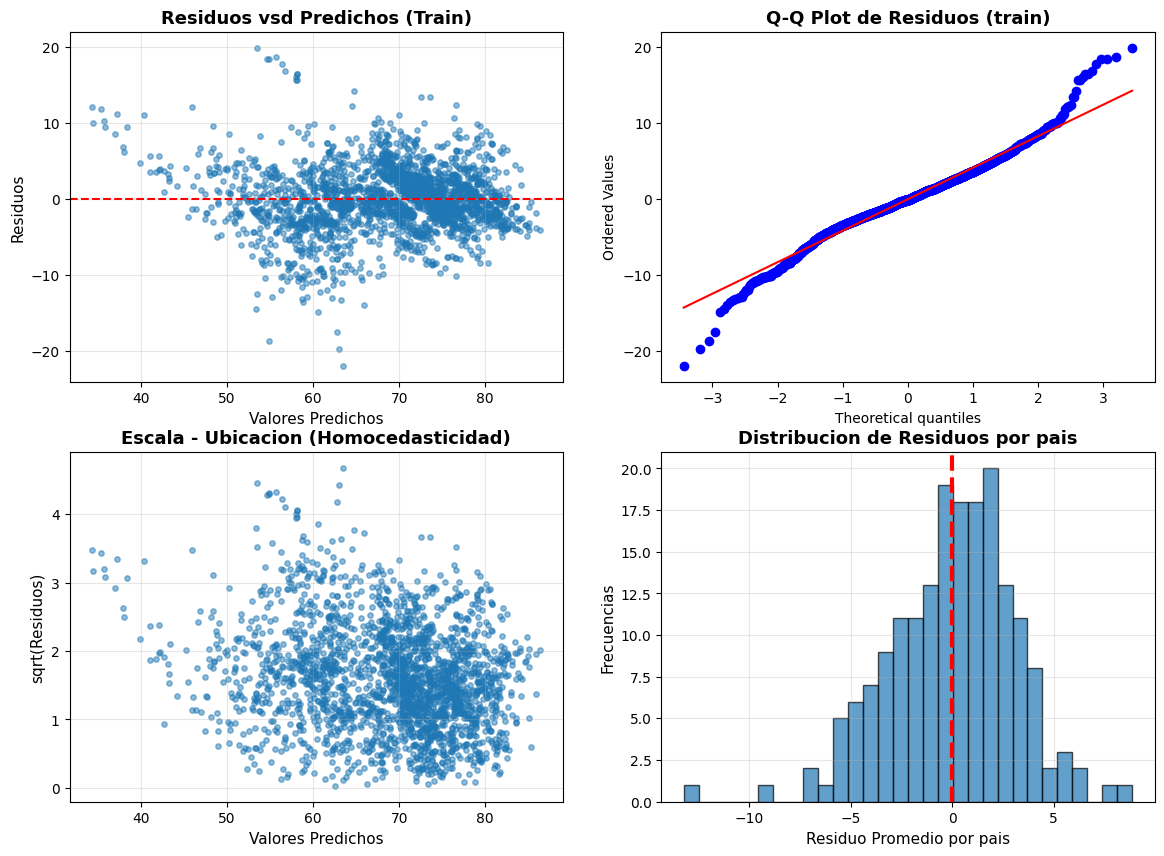

In [31]:
# Calculo de residuos para train y test
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Generemos la matriz 2x2
fig, axes  = plt.subplots(2,2, figsize = (14,10))

# Residuals vs Fitter
axes[0,0].scatter(y_pred_train, residuals_train, alpha = 0.5, s = 15)
axes[0,0].axhline(0 , color = "red", linestyle = "--")
axes[0,0].set_title("Residuos vsd Predichos (Train)", fontsize = 13, fontweight = "bold")
axes[0,0].set_xlabel("Valores Predichos", fontsize =11)
axes[0,0].set_ylabel("Residuos", fontsize =11)
axes[0,0].grid(alpha = 0.3)

# Q-Q plot
stats.probplot(residuals_train, dist = "norm", plot = axes[0,1])
axes[0,1].set_title("Q-Q Plot de Residuos (train)", fontsize = 13, fontweight = "bold")

# Escala-Location (sqrt(|residuos|) vs predichos)
axes[1,0].scatter(y_pred_train, np.sqrt(np.abs(residuals_train)), alpha = 0.5, s = 15)
axes[1,0].set_title("Escala - Ubicacion (Homocedasticidad)", fontsize = 13, fontweight = "bold")
axes[1,0].set_xlabel("Valores Predichos", fontsize =11)
axes[1,0].set_ylabel("sqrt(Residuos)", fontsize =11)
axes[1,0].grid(alpha = 0.3)

# Residuos por pais
country_residuals = (
    df_train
    .groupby("Country")
    .apply(
        lambda g: (
            g[target] - model.predict(
                scaler_X_final.transform(g[predictors].values)
            )
        ).mean(),
        include_groups=False
    )
)

axes[1,1].hist(country_residuals, bins = 30, edgecolor = "black", alpha = 0.7)
axes[1,1].axvline(0, color = "red", linestyle = "--", linewidth = 3)
axes[1,1].set_xlabel("Residuo Promedio por pais", fontsize = 11)
axes[1,1].set_ylabel("Frecuencias", fontsize = 11)
axes[1,1].set_title("Distribucion de Residuos por pais", fontsize = 13, fontweight = "bold")
axes[1,1].grid(alpha = 0.3)

plt.show()